<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Copy_of_Exp3_Neural_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 256s 2us/step


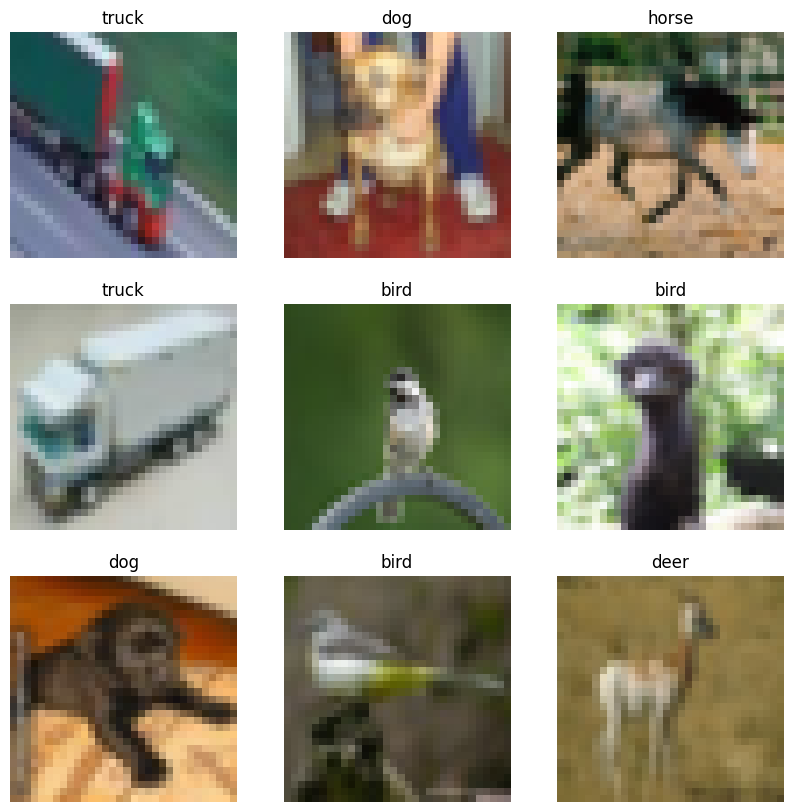

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,346 (2.86 MB)

 Trainable params: 750,346 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 232ms/step - accuracy: 0.4486 - loss: 1.5143 - val_accuracy: 0.5563 - val_loss: 1.2299
Epoch 2/15
273/782 ━━━━━━━━━━━━━━━━━━━━ 1:47 211ms/step - accuracy: 0.5666 - loss: 1.1978

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Labels
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Display Sample Images - Changed to show DIFFERENT images (indices 50 to 58)
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    # Offset by 50 to show a different set of pictures
    img_index = i + 50
    plt.imshow(X_train[img_index])
    plt.title(class_names[y_train[img_index][0]])
    plt.axis('off')

plt.show()

# Build CNN Model
model = models.Sequential()

# First Convolution Layer - Increased filters to 64
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer - Increased filters to 128
model.add(layers.Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Layer - Increased filters to 128
model.add(layers.Conv2D(
    128,
    (3,3),
    activation='relu'
))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layers - Increased neurons to 256
model.add(layers.Dense(256, activation='relu'))

model.add(layers.Dense(
    10,
    activation='softmax'
))

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model - Added batch_size and changed to 15 epochs for new outputs
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_data=(X_test, y_test)
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()